In [1]:
import pandas as pd
from prophet import Prophet
from prophet import Prophet
from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

import warnings
warnings.filterwarnings("ignore")

data = pd.read_csv('/kaggle/input/newdata/ProductionDataAll - Copy.csv')

In [2]:
# fill missing values
data['Temperature'] = data['Temperature'].interpolate()

In [3]:
# format for prophet
data['ds'] = pd.to_datetime(data['Date'])
data['y'] = data['Temperature']

In [4]:
# unique countries
countries = data['Country'].unique()

In [5]:
#convert the date column to datetime
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values(by='Date')

In [6]:
#split the data into train and test
train = data[data['Date'].dt.year <= 2019]
test = data[data['Date'].dt.year > 2019]

In [7]:
#create a separate model for each country
all_forecast = []  # List to store all forecasts

for country in countries:
    country_data = train[train['Country'] == country][['ds', 'y']]
    model_test = Prophet()
    model_test.fit(country_data)

    # Make predictions for each country within the loop
    future = model_test.make_future_dataframe(periods=60, freq='M')
    forecast = model_test.predict(future)

    # Add a 'Country' column to the forecast DataFrame
    forecast['Country'] = country

    # Append the forecast to the list
    all_forecast.append(forecast)

# Concatenate all forecasts into a single DataFrame
forecasts_test = pd.concat(all_forecast, ignore_index=True)

13:21:57 - cmdstanpy - INFO - Chain [1] start processing
13:21:57 - cmdstanpy - INFO - Chain [1] done processing
13:21:58 - cmdstanpy - INFO - Chain [1] start processing
13:21:58 - cmdstanpy - INFO - Chain [1] done processing
13:21:58 - cmdstanpy - INFO - Chain [1] start processing
13:21:58 - cmdstanpy - INFO - Chain [1] done processing
13:21:58 - cmdstanpy - INFO - Chain [1] start processing
13:21:58 - cmdstanpy - INFO - Chain [1] done processing
13:21:59 - cmdstanpy - INFO - Chain [1] start processing
13:21:59 - cmdstanpy - INFO - Chain [1] done processing
13:21:59 - cmdstanpy - INFO - Chain [1] start processing
13:21:59 - cmdstanpy - INFO - Chain [1] done processing
13:21:59 - cmdstanpy - INFO - Chain [1] start processing
13:21:59 - cmdstanpy - INFO - Chain [1] done processing
13:22:00 - cmdstanpy - INFO - Chain [1] start processing
13:22:00 - cmdstanpy - INFO - Chain [1] done processing
13:22:00 - cmdstanpy - INFO - Chain [1] start processing
13:22:00 - cmdstanpy - INFO - Chain [1]

In [8]:
# Extract forecasts for years > 2019 for testing
pred_forcast = forecasts_test[forecasts_test['ds'].dt.year > 2019]

In [9]:
# Extract forecasts for years > 2019 for testing, ensuring alignment with test data
pred_forcast = forecasts_test[(forecasts_test['ds'].dt.year > 2019) & (forecasts_test['Country'].isin(test['Country']))]


# Merge pred_forcast and test on 'ds' and 'Country' to align data
# Convert 'ds' to datetime objects with the same format as 'Date' in test DataFrame

# Convert 'ds' to the first day of the month
pred_forcast['ds'] = pred_forcast['ds'].dt.to_period('M').dt.to_timestamp()

pred_forcast['ds'] = pd.to_datetime(pred_forcast['ds']).dt.normalize()  # Normalize to remove time component
test['Date'] = pd.to_datetime(test['Date']).dt.normalize()          # Normalize to remove time component
pred_forcast = pd.merge(pred_forcast, test, left_on=['ds', 'Country'], right_on=['Date', 'Country'])

# Check if pred_forcast is empty before calculating metrics
if not pred_forcast.empty:
    mae = mean_absolute_error(pred_forcast['yhat'], pred_forcast['y'])  # Use merged DataFrame for consistent data
    mse = mean_squared_error(pred_forcast['yhat'], pred_forcast['y'])
    mape = mean_absolute_percentage_error(pred_forcast['yhat'], pred_forcast['y'])
    rmse = sqrt(mse)
    print(f'MAE: {mae}, RMSE: {rmse}, MAPE: {mape}',)
else:
    print("pred_forcast DataFrame is empty. Check for data mismatches.")

MAE: 1.5303019426412152, RMSE: 2.3624942920959793, MAPE: 0.09795895130632765


In [10]:
#create a separate model for each country with all data
all_forecasts = []  # List to store all forecasts

for country in countries:
    country_data = data[data['Country'] == country][['ds', 'y']]
    model = Prophet()
    model.fit(country_data)

    # Make predictions for each country within the loop
    future = model.make_future_dataframe(periods=60, freq='M')
    forecast = model.predict(future)

    # Add a 'Country' column to the forecast DataFrame
    forecast['Country'] = country

    # Append the forecast to the list
    all_forecasts.append(forecast)

# Concatenate all forecasts into a single DataFrame
forecasts = pd.concat(all_forecasts, ignore_index=True)

13:22:01 - cmdstanpy - INFO - Chain [1] start processing
13:22:01 - cmdstanpy - INFO - Chain [1] done processing
13:22:01 - cmdstanpy - INFO - Chain [1] start processing
13:22:01 - cmdstanpy - INFO - Chain [1] done processing
13:22:02 - cmdstanpy - INFO - Chain [1] start processing
13:22:02 - cmdstanpy - INFO - Chain [1] done processing
13:22:02 - cmdstanpy - INFO - Chain [1] start processing
13:22:02 - cmdstanpy - INFO - Chain [1] done processing
13:22:02 - cmdstanpy - INFO - Chain [1] start processing
13:22:02 - cmdstanpy - INFO - Chain [1] done processing
13:22:03 - cmdstanpy - INFO - Chain [1] start processing
13:22:03 - cmdstanpy - INFO - Chain [1] done processing
13:22:03 - cmdstanpy - INFO - Chain [1] start processing
13:22:03 - cmdstanpy - INFO - Chain [1] done processing
13:22:03 - cmdstanpy - INFO - Chain [1] start processing
13:22:03 - cmdstanpy - INFO - Chain [1] done processing
13:22:04 - cmdstanpy - INFO - Chain [1] start processing
13:22:04 - cmdstanpy - INFO - Chain [1]

In [11]:
# Extract forecasts for years > 2019 for testing
prophet_forcast = forecasts[forecasts['ds'].dt.year > 2024]
# Convert 'ds' to the first day of the month
prophet_forcast['ds'] = prophet_forcast['ds'].dt.to_period('M').dt.to_timestamp() # Changed 'prophet_forcast' to 'to_period'

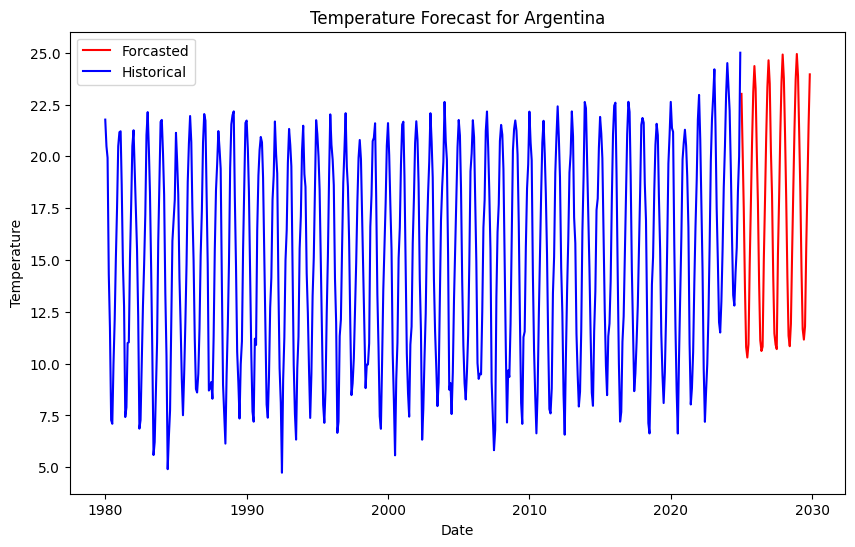

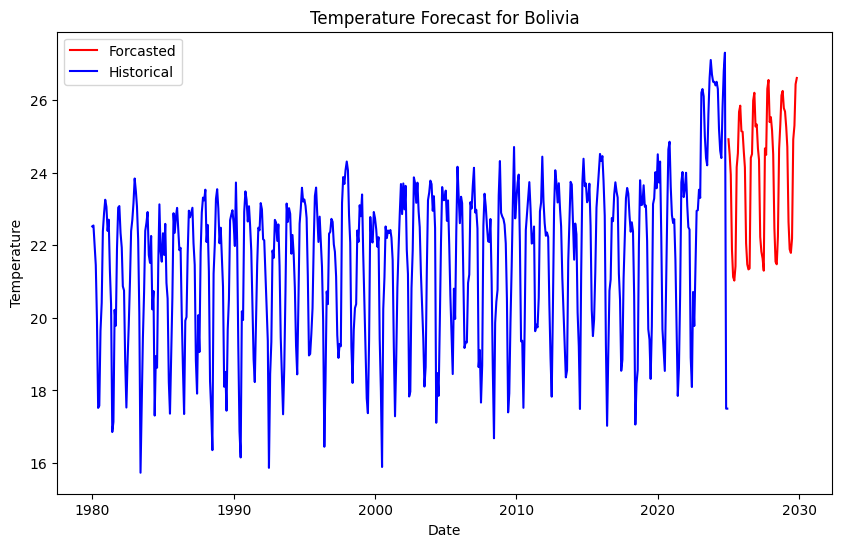

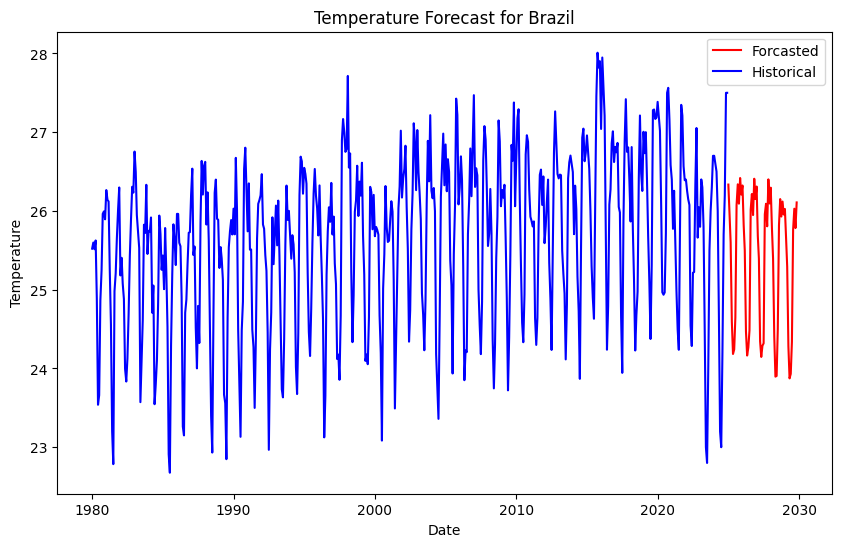

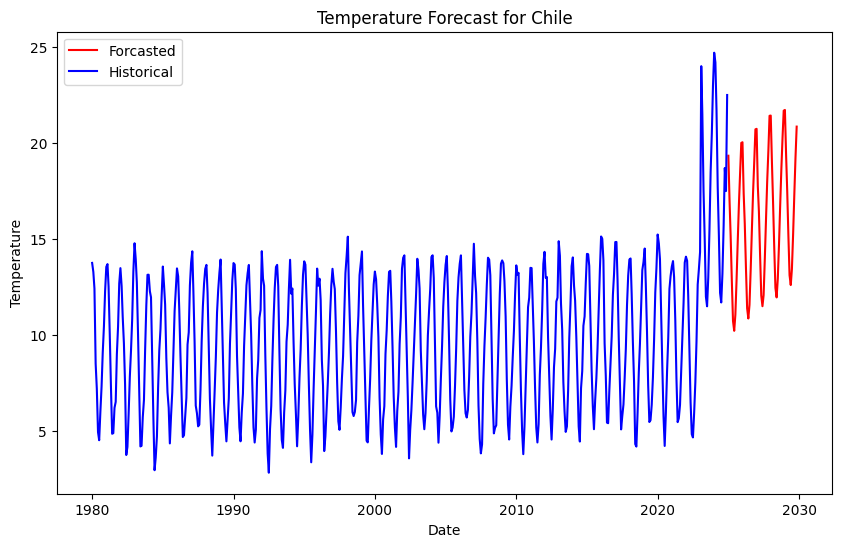

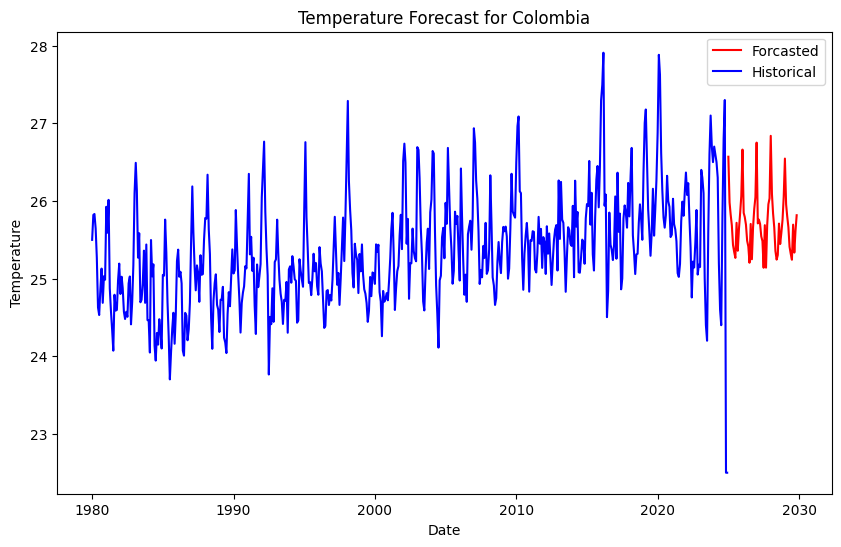

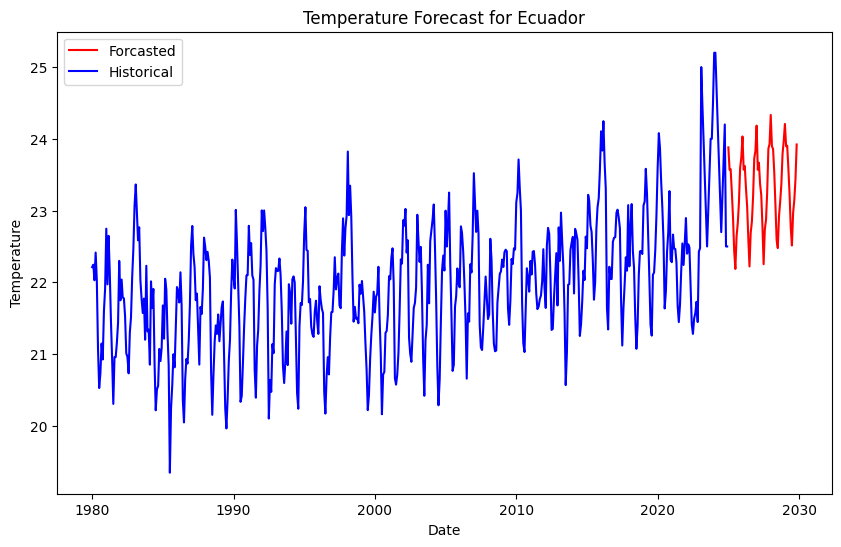

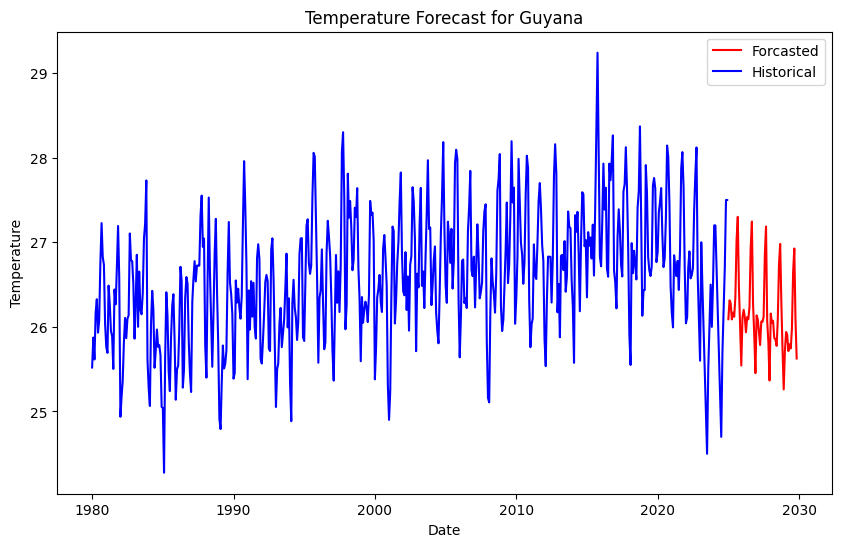

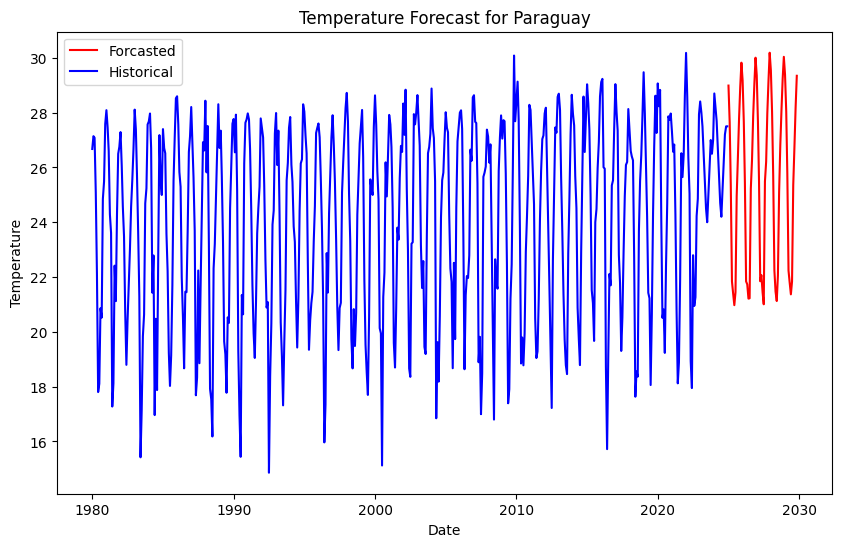

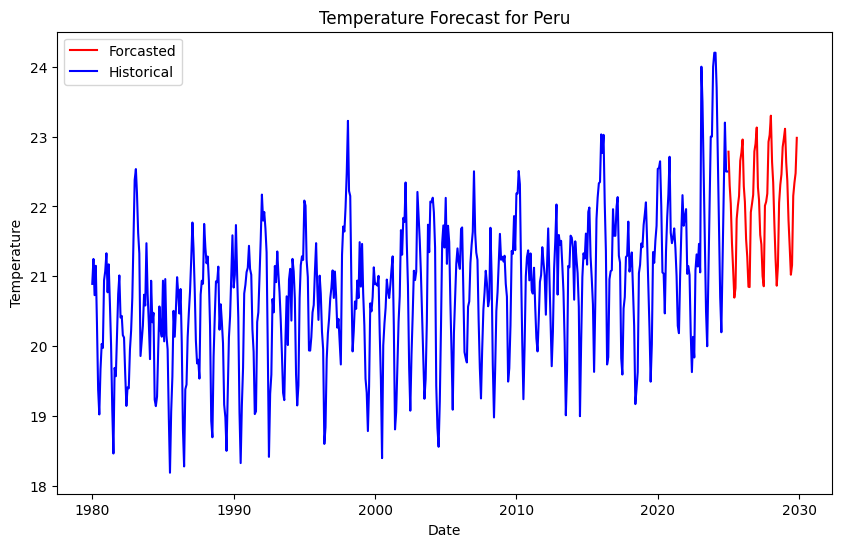

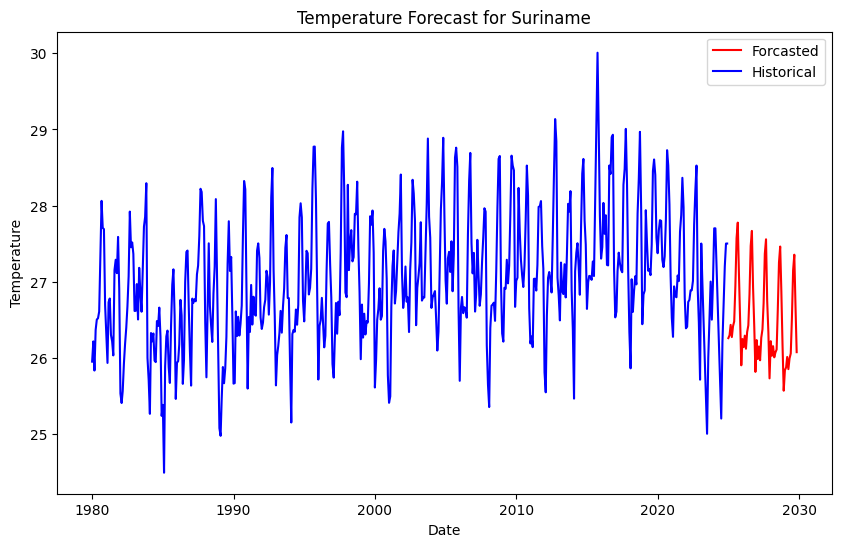

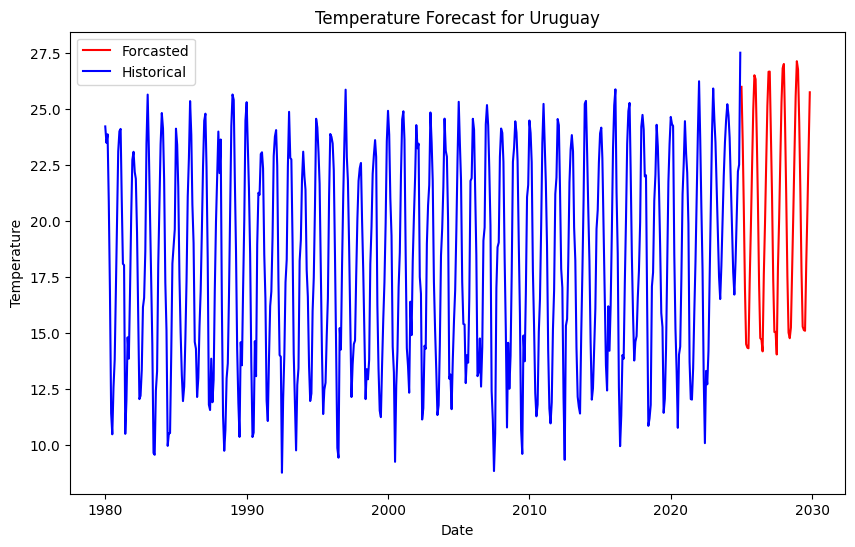

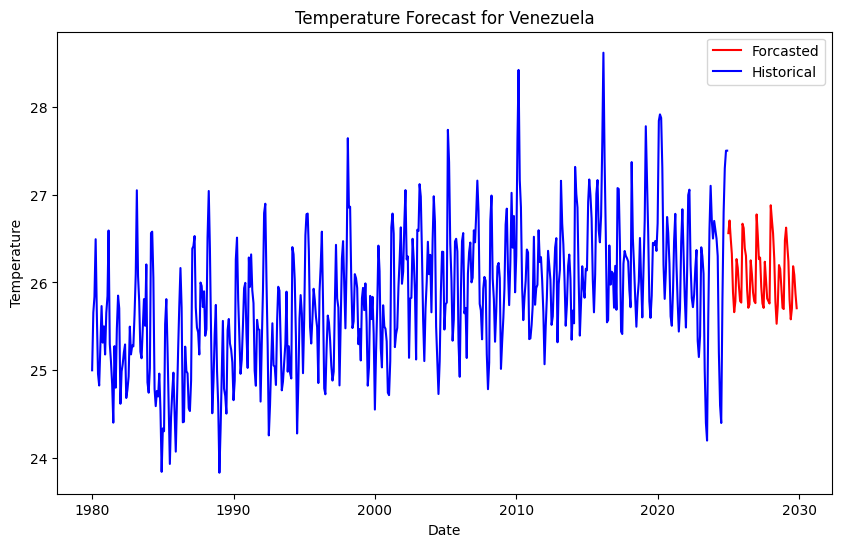

In [12]:
#plot for each country
import matplotlib.pyplot as plt
for country in countries:
    # Filter forecasts for the current country
    country_forecasts = prophet_forcast[prophet_forcast['Country'] == country]
    real = data[data['Country'] == country]
    # Now plot using the filtered DataFrame
    plt.figure(figsize=(10, 6))
    plt.xlabel('Date')
    plt.ylabel('Temperature')
    plt.plot(country_forecasts['ds'], country_forecasts['yhat'], color = 'r', label='Forcasted' )
    plt.plot(real['ds'], real['y'],label='Historical', color = 'b' )
    plt.title(f'Temperature Forecast for {country}')
    plt.legend()
    plt.show()

In [13]:
# save the predictions to a CSV file as country, date and temperature
prophet_forcast = prophet_forcast[['Country', 'ds', 'yhat']]
# rename column ds as Date and yhat as Temperature
prophet_forcast = prophet_forcast.rename(columns={'ds': 'Date', 'yhat': 'Temperature'})

# save the predictions to a CSV file
prophet_forcast.to_csv('Prophet Data.csv')